# Analysis: Step 2
This is the step where we create summaries of the data.

In [8]:
# Install the local requirements.
%pip install pandas seaborn geopandas iso3166 mapclassify polars

Note: you may need to restart the kernel to use updated packages.


In [9]:
# The URL to the directory of manually-verified and -reviewed summary stats (in .json files)
from typing import Any, Literal, Callable, TypeVar, TypedDict
from pandas._libs.missing import NAType

SUMMARY_DIR: str = "p1_reviewed/"

# Path to list of papers that were included
INCLUDED_PAPERS: str = "./included.csv"

# Fields
FIELDS = {
    "EVIDENCED": ["age_range", "fieldwork_year", "gender_split", "countries", "sample_size"],
    "NON-EVIDENCED": ["category"]
}

T = TypeVar("T")
OrNA = T | NAType

class Summary(TypedDict):
    paper_id: int
    category: Literal["Review", "Experiment"]
    fieldwork_year: OrNA[int]
    countries: list[str]
    sample_size: OrNA[int]
    age_range_lower: OrNA[int]
    age_range_upper: OrNA[int]
    gender_female: OrNA[int]
    gender_male: OrNA[int]
    gender_other: OrNA[int]


In [10]:
import rapidjson
import os
from itertools import product
import pandas as pd

T = TypeVar("T")
def get_or_none(dict: dict[str, Any], key: str, map: Callable[[Any], T | None]) -> T | None:
    v = dict.get(key)
    if v is None:
        return None
    
    return map(v)

# Load in summaries

raw_summaries = [(p.replace(".json", ""), rapidjson.load(open(os.path.join(SUMMARY_DIR, p)))) for p in os.listdir(SUMMARY_DIR)]

def to_summary(path: str, raw_summary: dict[str, Any]) -> Summary:
    # Some papers happened to contain multiple studies within them,
    #   We will still count them separately here.

    # Note, we do not do this if the sample decreases within the same
    # study (e.g. responses drop off). 
    if "_" in path:
        path, _ = path.split("_", maxsplit=1)

    age_range_lower, age_range_upper = get_or_none(raw_summary, "age_range", lambda v: tuple(v["value"])) or (pd.NA, pd.NA)
    gender_female, gender_male, gender_other = get_or_none(raw_summary, "gender_split", lambda v: (v["value"]["female"], v["value"]["male"], v["value"]["other"])) or (pd.NA, pd.NA, pd.NA)
    
    return Summary(
        paper_id= int(path),
        category=raw_summary["category"],
        fieldwork_year=get_or_none(raw_summary, "fieldwork_year", lambda v: v["value"]) or pd.NA,
        countries=get_or_none(raw_summary, "countries", lambda v: [c.strip() for c in v["value"]]) or [],
        sample_size=get_or_none(raw_summary, "sample_size", lambda v: v["value"]) or pd.NA,
        age_range_lower=age_range_lower,
        age_range_upper=age_range_upper,
        gender_female=gender_female,
        gender_male=gender_male,
        gender_other=gender_other
    )


study_summaries = pd.DataFrame.from_records((to_summary(p, s) for (p, s) in raw_summaries))

paper_metadata = pd.read_csv(INCLUDED_PAPERS)

studies = pd.merge(study_summaries, paper_metadata, how="left", left_on="paper_id", right_on=paper_metadata.index)

studies = studies.astype({
    "fieldwork_year": "Int64",
    "sample_size": "Int64",
    "gender_female": "Int64",
    "gender_male": "Int64",
    "gender_other": "Int64",
    "age_range_lower": "Int64",
    "age_range_upper": "Int64",
})

N=38


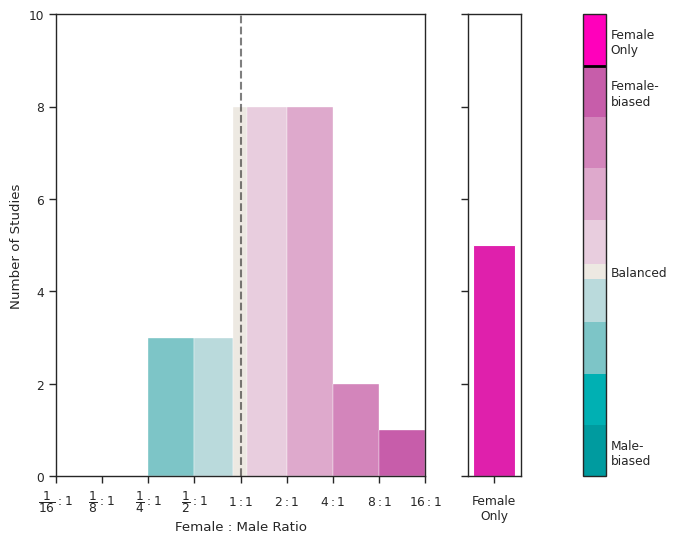

In [11]:
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)
sns.set_theme("paper", "ticks")

fm_ratio = (studies.gender_female / studies.gender_male).dropna()
print(f"N={fm_ratio.count()}")

female_only, fm_ratio = fm_ratio[np.isinf(fm_ratio)], fm_ratio[np.isfinite(fm_ratio)]

colors = [
    "#009B9F",
    "#00B0B3",
    "#7DC5C7",
    "#BADADC",
    "#EDE9E2",
    "#E8CDDE",
    "#DEA9CC",
    "#D385BB",
    "#C75DAA",
    "#FF00BB"
]


fig, (ax, ax_female_only) = plt.subplots(1, 2, width_ratios=(7, 1), figsize=(8, 6), sharey=True)

sns.histplot(
    fm_ratio,
    bins=[1/8, 1/4, 1/2, 0.9, 1.1, 2, 4, 8, 16],
    ax=ax,
)

for (patch, color) in zip(ax.patches, colors[1:]):
    patch.set_color(color)
    patch.set_edgecolor("white")

sns.barplot(
    x=[0],
    y=[female_only.count()],
    color=colors[-1],
    ax=ax_female_only,
)

X_PAD = 16

ax_female_only.set_xticks([0], labels=["Female\nOnly"], verticalalignment='baseline')
ax_female_only.tick_params(
    axis='x', pad=X_PAD+10, 
)

ax.set_xlim(1/16, 16)
ax.set_ylim(0, 10)
ax.set_xscale("log", base=2)
ax.set_xticks(
    [1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16], 
    labels=[r"$\dfrac{1}{16}:1$", r"$\dfrac{1}{8}:1$", r"$\dfrac{1}{4}:1$", r"$\dfrac{1}{2}:1$", "$1:1$",  r"$2:1$", r"$4:1$",r"$8:1$", r"$16:1$"], 
    minor=False,
    verticalalignment='baseline',
)
ax.tick_params(axis='x', pad=X_PAD)

ax.axvline(1, color="black", linestyle="--", linewidth=1.5, alpha=0.5)

bounds = [-4, -3, -2, -1, np.log2(0.9), np.log2(1.1), 1, 2, 3, 4, 5]
cmap = ListedColormap(colors, "gender-test")
norm = BoundaryNorm(bounds, ncolors=len(colors))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=[ax, ax_female_only],
    spacing="proportional",
    boundaries=bounds,
    pad=0.1
)

cbar.set_ticks([4.5, 3.5, 0, -3.5], labels=["Female\nOnly", "Female-\nbiased", "Balanced", "Male-\nbiased"])
cbar.set_ticks([], minor=True)
cbar.ax.tick_params(length=0)
cbar.ax.axhline(4, color='black', linewidth=2)

ax.xaxis.set_label_text("Female : Male Ratio")
ax.yaxis.set_label_text("Number of Studies")
fig.savefig("figs/studies-gender-balance.pdf", transparent=True)

AttributeError: 'Series' object has no attribute 'fieldwork_year'

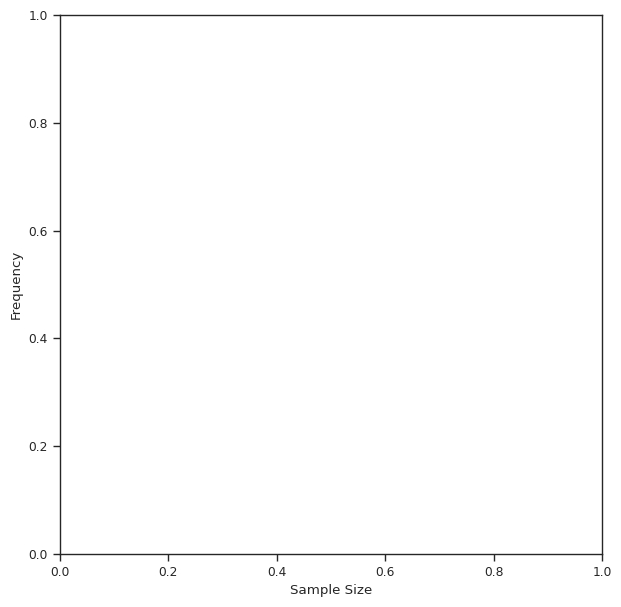

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
# ax.set(xscale="log")

ax.xaxis.label.set_text("Sample Size")
ax.yaxis.label.set_text("Frequency")
# ax.xaxis.set_ticks([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
# ax.xaxis.set_tick_params(which="both", labelrotation=60)


hist = studies["sample_size"].dropna()

# ax.set_title(f"Fieldwork of Studies $(N={len(hist)})$")

hist = hist.fieldwork_year.value_counts()

ax = sns.barplot(
    x=hist.index,
    y=hist.values,
    orient="v"
)


Unique countries:  ['KOR', 'CHE', 'COL', 'ARG', 'PER', 'IND', 'TWN', 'AUT', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'EST', 'FIN', 'GRC', 'HRV', 'HUN', 'IRL', 'LTU', 'LUX', 'LVA', 'MLT', 'POL', 'PRT', 'SWE', 'SVN', 'SVK', 'IRN', 'NOR', 'VNM', 'BEL', 'ESP', 'ROU', 'TUR', 'ITA', 'FRA', 'CAN', 'AUS', 'CHN', 'NLD', 'GBR', 'USA']
\begin{tabular}{ll}
\toprule
 & 0 \\
frequency &  \\
\midrule
1 & Argentina, Austria, Bulgaria, Colombia, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, Germany, Greece, Hungary, India, Iran, Islamic Republic of, Ireland, Korea, Republic of, Latvia, Lithuania, Luxembourg, Malta, Norway, Peru, Poland, Portugal, Slovakia, Slovenia, Sweden, Switzerland, Taiwan, Province of China, Viet Nam \\
2 & Belgium, France, Italy, Romania, Spain, Türkiye \\
3 & Australia, Canada, China, Netherlands \\
5 & United Kingdom of Great Britain and Northern Ireland \\
14 & United States of America \\
\bottomrule
\end{tabular}



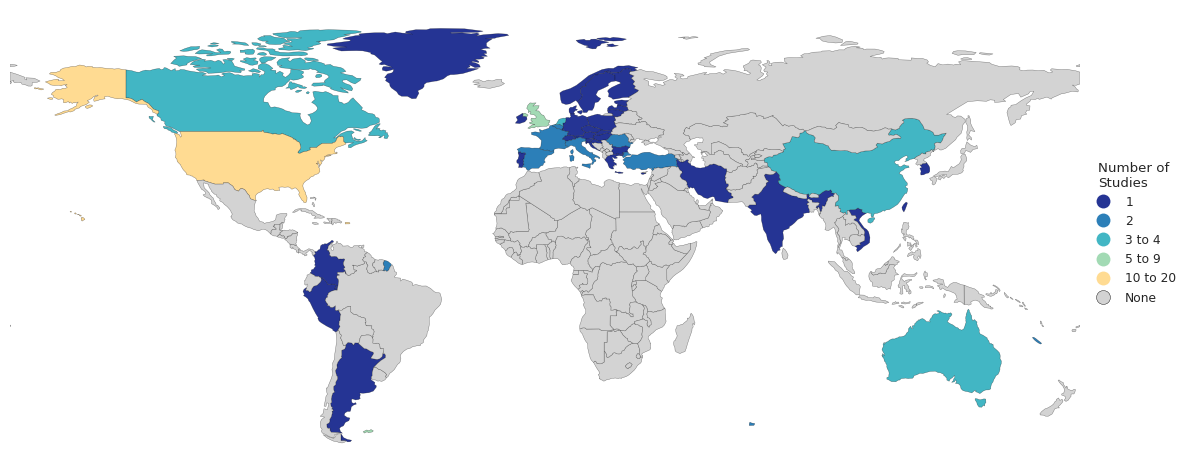

In [ ]:
import geopandas as geopd
from IPython.display import display_html
from iso3166 import countries_by_alpha2, countries_by_alpha3
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize

freq_by_country: pd.Series[int] = pd.Series([x for study in studies.countries.to_list() for x in study]).value_counts()
freq_by_country.name = "frequency"
freq_by_country = pd.Series(freq_by_country.values, index=freq_by_country.index.map(lambda a2: countries_by_alpha2[a2].alpha3), dtype="Int64", name="frequency")
# print(countries)

world = geopd.read_file("./geo/ne_110m_admin_0_sovereignty.shp")
# ax.set_rasterized(False)

# print(world)
world = world.merge(freq_by_country, how="left", left_on="ISO_A3_EH", right_on=freq_by_country.index)
world.frequency = world.frequency.astype("Int64")
# world.assign(frequency=lambda x: print(x))


fig, ax = plt.subplots(1, 1, figsize=(12, 6))
# ax.set(xscale="log")

# ax.xaxis.label.set_text("")
# ax.yaxis.label.set_text("")
ax.axis("off")

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 90)

bins = {
    "values": [1.99, 2.99, 4.99, 9.99, 20],
    "labels": ["1", "2", "3 to 4", "5 to 9", "10 to 20"]
}

colormap = LinearSegmentedColormap.from_list("test", ['#253494', '#2c7fb8', '#41b6c4','#a1dab4', "#ffdb92",])

world.plot(
    column='frequency',
    ax=ax,
    scheme='UserDefined',
    classification_kwds={'bins':  bins["values"]},
    legend=True,
    cmap=colormap,
    edgecolor='#00000080',
    linewidth=0.3,
    legend_kwds={
        'loc': 'center left',
        'title': 'Number of\nStudies',
        'frameon': False,
        'bbox_to_anchor': (1.0, 0.5),
    },
    missing_kwds={"color": "lightgray"}
)

legend_labels = ax.get_legend().get_texts()
legend_labels[-1].set_text("None")

for (label, lg) in zip(bins["labels"], legend_labels):
    lg.set_text(label)

fig.tight_layout()
ax.set_axis_off()
# ax.set_title(f"Geographical Focus of Studies $(N={studies.countries.apply(lambda l: len(l) > 0).sum()})$")

fig.savefig("figs/studies-map.pdf", transparent=True)

freq_by_country_grouped = freq_by_country.to_frame().reset_index().groupby("frequency")

print("Unique countries: ", [c for group in freq_by_country_grouped.index.unique().values.tolist() for c in group])

print(freq_by_country_grouped.apply(lambda a: ", ".join(sorted(countries_by_alpha3[c].name for c in a["index"]))).to_latex())

shape: (1, 28)
┌─────────────────┬─────────────────┬───────┬───────┬───┬────────┬────────┬────────┬────────┐
│ age_range_lower ┆ age_range_upper ┆ age_0 ┆ age_1 ┆ … ┆ age_22 ┆ age_23 ┆ age_24 ┆ age_25 │
│ ---             ┆ ---             ┆ ---   ┆ ---   ┆   ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ u32             ┆ u32             ┆ u32   ┆ u32   ┆   ┆ u32    ┆ u32    ┆ u32    ┆ u32    │
╞═════════════════╪═════════════════╪═══════╪═══════╪═══╪════════╪════════╪════════╪════════╡
│ 37              ┆ 37              ┆ 37    ┆ 37    ┆ … ┆ 37     ┆ 37     ┆ 37     ┆ 37     │
└─────────────────┴─────────────────┴───────┴───────┴───┴────────┴────────┴────────┴────────┘


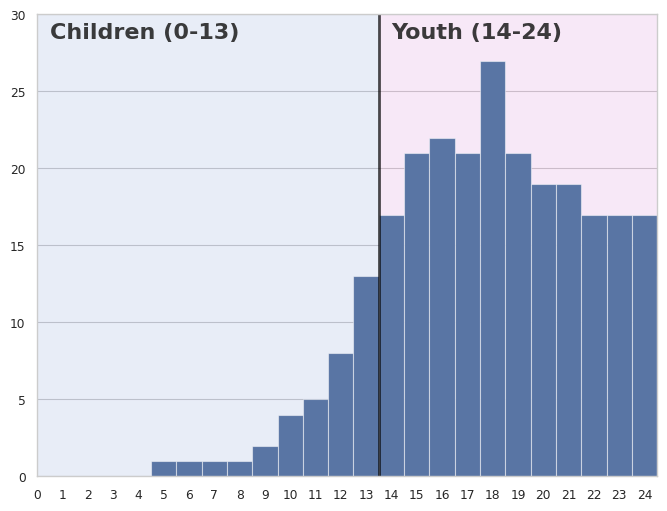

In [152]:
from matplotlib.patches import Patch, Rectangle
import polars as pl

sns.set_theme("paper", "whitegrid")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))


age_range = list(range(26))

by_ages = pl.DataFrame._from_pandas(studies[["age_range_lower", "age_range_upper"]].dropna())
by_ages = by_ages.with_columns(**{
    f"age_{i}": (i >= pl.col("age_range_lower") ).and_(i <= pl.col("age_range_upper")) for i in age_range
})

print(by_ages.count())
ax.add_patch(Rectangle(xy=(-0.5, 0), width=14, height=30, facecolor="#4E74C720", edgecolor="#00000000"))
ax.add_patch(Rectangle(xy=(13.5, 0), width=11, height=30, facecolor="#C74EC120", edgecolor="#00000000"))
ax.set_xticks([*age_range, age_range[-1] + 0.5], labels=[*(f"{f}" for f in age_range), ""])
sns.barplot(
    x=np.array(list([age -0.5 for age in age_range])),
    y=by_ages.select(pl.col(r"^age_[\d]*$")).sum().to_numpy()[0],
    gap=0.0,
    width=1.0,
    ax=ax,
    edgecolor="#ffffff80"
    # color="#ad1759"
)

ax.set_ylim(0, 30)
ax.set_xlim(0, 24.5)


ax.axvline(13.5, color='black', linestyle="-", linewidth=2, alpha=0.7)
ax.text(0.5, 29.5, "Children (0-13)", horizontalalignment="left", verticalalignment="top", fontsize=16, fontweight='bold', alpha=0.9)
ax.text(14, 29.5, "Youth (14-24)", horizontalalignment="left", verticalalignment="top", fontsize=16, fontweight='bold', alpha=0.9)

# by_ages.select(pl.col(r"^age_[\d]*$")).sum().to_numpy()

fig.savefig("figs/studies-ages.pdf", transparent=True)

[3 2 2 2 8 6 8 3 4 4 2 1 1 3 1 6 2 1 2 3 2 6 2 8 4 2 2]
N = 27



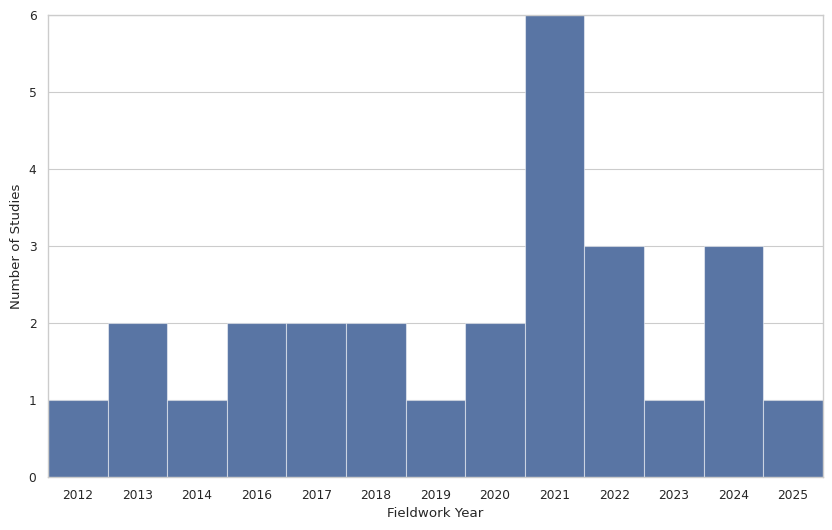

In [211]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6), width_ratios=(8,))

S = pl.DataFrame._from_pandas(studies)
with_fw_years = S.filter(pl.col("fieldwork_year").is_not_null())

time_to_study = with_fw_years.select((pl.col("Published Year") - pl.col("fieldwork_year"))).to_numpy().T[0]
print(time_to_study)
sns.boxplot(y=time_to_study, ax=ax2)

years = with_fw_years["fieldwork_year"].cast(pl.Int64)
print("N =",years.count())

print()
sns.barplot(
   years.value_counts(),
    x="fieldwork_year",
    y="count",
    gap=0.0,
    width=1.0,
    ax=ax,
    edgecolor="#ffffff80"
)

ax.set_ylabel("Number of Studies")
ax.set_xlabel("Fieldwork Year")

ax.set_ylim(0, 6)

fig.savefig("figs/studies-fieldwork.pdf")

# ax.set_xticks(ax.get_xticks(), labels=[t.get_text()[:] for t in ax.get_xticklabels()])